# A/B 테스트 종합 과제 — 패스트푸드 프로모션 매출 비교

**데이터셋**: Fast Food Marketing Campaign A/B Test
**출처**: Kaggle — https://www.kaggle.com/datasets/chebotinaa/fast-food-marketing-campaign-ab-test
**내려받은 날짜**: 2026-07-31 (※ 실제 다운로드한 날짜로 수정하세요)

**데이터 설명**: 137개 매장을 3가지 프로모션(1, 2, 3) 중 하나에 배정하고, 4주간(week 1~4)의 주간 매출(SalesInThousands, 단위: 천 달러)을 기록한 데이터입니다.

| 컬럼 | 설명 |
|---|---|
| MarketID | 시장(지역) ID |
| MarketSize | 시장 규모 (Small/Medium/Large) |
| LocationID | 매장 ID |
| AgeOfStore | 매장 운영 연수 |
| Promotion | 배정된 프로모션 (1, 2, 3) |
| week | 관측 주차 (1~4) |
| SalesInThousands | 주간 매출 (단위: 천 달러) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('WA_Marketing-Campaign.csv')
df.shape


(548, 7)

## 1️⃣ 데이터 점검

In [2]:
# 기본 확인 — 행 수, 컬럼, 자료형, 결측치
print(df.dtypes)
print()
print(df.isnull().sum())
print()
df.describe(include='all')


MarketID              int64
MarketSize              str
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
dtype: int64



,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.000000,548,548.000000,548.000000,548.000000,548.000000,548.000000
unique,NaN,3,NaN,NaN,NaN,NaN,NaN
top,NaN,Medium,NaN,NaN,NaN,NaN,NaN
freq,NaN,320,NaN,NaN,NaN,NaN,NaN
mean,5.715328,NaN,479.656934,8.503650,2.029197,2.500000,53.466204
std,2.877001,NaN,287.973679,6.638345,0.810729,1.119055,16.755216
min,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,17.340000
25%,3.000000,NaN,216.000000,4.000000,1.000000,1.750000,42.545000
50%,6.000000,NaN,504.000000,7.000000,2.000000,2.500000,50.200000
75%,8.000000,NaN,708.000000,12.000000,3.000000,3.250000,60.477500


In [3]:
# 중복 확인 — (LocationID, week) 조합이 유일해야 함 (같은 매장의 같은 주가 두 번 기록되면 안 됨)
dup_key = df.duplicated(subset=['LocationID', 'week']).sum()
dup_full = df.duplicated().sum()
print(f"(LocationID, week) 중복 조합 수: {dup_key}")
print(f"완전 중복 행 수: {dup_full}")


(LocationID, week) 중복 조합 수: 0
완전 중복 행 수: 0


In [4]:
# 배정 일관성 확인 — 한 매장(LocationID)이 여러 프로모션에 걸쳐 있으면 배정 오류
promo_per_store = df.groupby('LocationID')['Promotion'].nunique()
inconsistent_stores = promo_per_store[promo_per_store > 1]
print(f"프로모션이 2개 이상으로 기록된 매장 수: {len(inconsistent_stores)}")


프로모션이 2개 이상으로 기록된 매장 수: 0


In [5]:
# SRM 점검 — 매장이 세 프로모션에 의도한 비율(대략 균등)로 배정되었는가?
# 배정 단위는 '주(week)'가 아니라 '매장(LocationID)'이므로 매장 단위로 집계해서 확인합니다.
store_counts = df.groupby('Promotion')['LocationID'].nunique()
print(store_counts)

n_total = store_counts.sum()
expected = [n_total / 3] * 3
chi2, p_srm = stats.chisquare(store_counts.values, expected)
print(f"\nSRM 점검(카이제곱): chi2 = {chi2:.3f}, p = {p_srm:.4f}")
print("※ 여기서는 p가 커야 정상입니다 (= 의도한 균등 배정과 다르지 않다).")


Promotion
1    43
2    47
3    47
Name: LocationID, dtype: int64

SRM 점검(카이제곱): chi2 = 0.234, p = 0.8898
※ 여기서는 p가 커야 정상입니다 (= 의도한 균등 배정과 다르지 않다).


**메모 (데이터 위생 점검 결과)**

- 결측치: 없음
- (매장, 주차) 중복: 없음 — 각 매장의 각 주차가 정확히 한 번씩만 기록됨
- 배정 일관성: 위반 매장 0개 — 모든 매장이 4주 내내 하나의 프로모션에만 배정되어 있음
- SRM: 매장 수가 세 그룹에 걸쳐 크게 치우치지 않음 (p ≥ 0.05 → 배정 로직에 이상 신호 없음)
- **정제 전후 행 수**: 원본 548행 → 위생 문제가 발견되지 않아 **행 제거 없이 548행 그대로 사용**
- **⚠️ 구조적으로 짚어야 할 점**: 이 데이터는 매장(LocationID) 1개당 4개 행(주차별)이 존재하는 **반복측정(패널) 구조**입니다. 548행을 그대로 독립표본처럼 취급하면 같은 매장의 4개 관측치가 서로 강하게 상관되어 있어 **가짜로 표본이 부풀려지는 문제(pseudo-replication)**가 생깁니다. 따라서 본 분석의 **1차 검정 단위는 '매장'**으로 정하고, 매장별 4주 평균 매출을 사용합니다. 원본 행 단위 분석과의 차이는 5단계에서 별도로 비교합니다.

In [6]:
# 분석 단위를 매장(LocationID)으로 집계 — 매장별 4주 평균 매출
store_df = df.groupby(['LocationID', 'Promotion'], as_index=False)['SalesInThousands'].mean()
print(store_df.shape)
store_df.groupby('Promotion')['SalesInThousands'].describe()


(137, 3)


,count,mean,std,min,25%,50%,75%,max
Promotion,,,,,,,,
1,43.0,58.099012,16.028223,37.785,48.69625,56.0750,61.32500,95.0900
2,47.0,47.329415,14.497097,27.840,37.43375,46.6550,49.94375,83.1575
3,47.0,55.364468,16.383866,31.185,45.36750,49.8525,60.24500,88.5775


## 2️⃣ 질문과 가설 정하기

**알고 싶은 것**: 세 가지 프로모션(1, 2, 3) 중 매장의 평균 매출을 가장 크게 올리는 것은 무엇인가?

- **귀무가설 $H_0$**: 세 프로모션 그룹 간 매장 평균 매출(4주 평균)의 모평균은 모두 같다. ($\mu_1 = \mu_2 = \mu_3$)
- **대립가설 $H_1$**: 적어도 한 프로모션 그룹의 모평균은 다른 그룹과 다르다.
- **유의수준**: $\alpha = 0.05$
- **검정 방향**: 양측 (어느 프로모션이 더 나은지 사전에 방향을 정하지 않음)

이 가설과 유의수준은 아래 검정을 실행하기 전에 확정하며, 결과를 본 뒤 바꾸지 않습니다.

## 3️⃣ 검정 고르기 ⭐

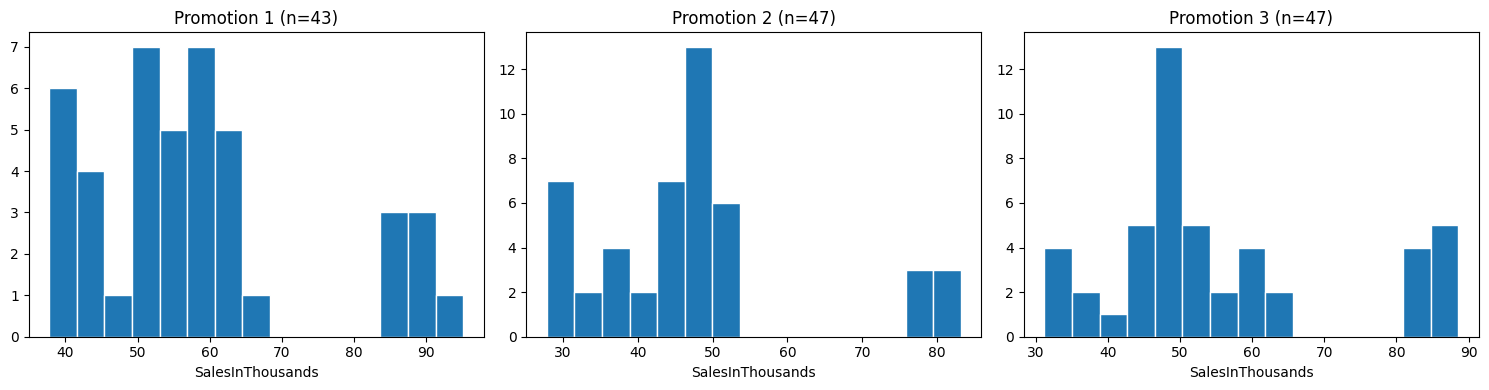

In [7]:
# 정규성 확인 — 히스토그램 + Q-Q plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, promo in enumerate([1, 2, 3]):
    data = store_df.loc[store_df['Promotion'] == promo, 'SalesInThousands']
    axes[i].hist(data, bins=15, edgecolor='white')
    axes[i].set_title(f'Promotion {promo} (n={len(data)})')
    axes[i].set_xlabel('SalesInThousands')
plt.tight_layout()
plt.show()


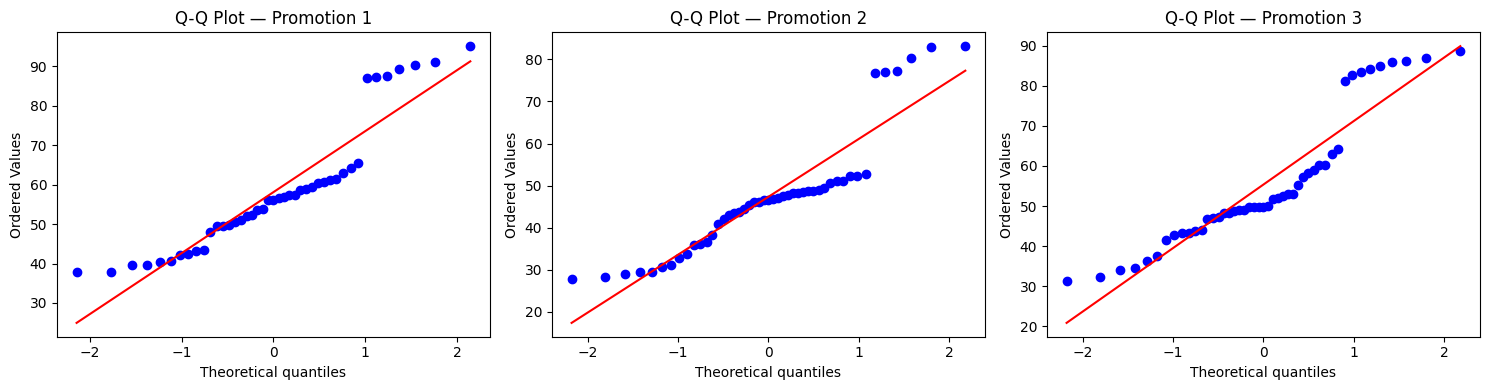

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, promo in enumerate([1, 2, 3]):
    data = store_df.loc[store_df['Promotion'] == promo, 'SalesInThousands']
    stats.probplot(data, dist='norm', plot=axes[i])
    axes[i].set_title(f'Q-Q Plot — Promotion {promo}')
plt.tight_layout()
plt.show()


In [9]:
# Shapiro-Wilk 정규성 검정 (그룹별)
print("[정규성: Shapiro-Wilk]")
for promo in [1, 2, 3]:
    data = store_df.loc[store_df['Promotion'] == promo, 'SalesInThousands']
    stat, p = stats.shapiro(data)
    print(f"  Promotion {promo}: W = {stat:.4f}, p = {p:.4f}  ->  {'정규성 위반 가능성' if p < 0.05 else '정규성 기각 못함(OK)'}")

# Levene 등분산 검정
groups = [store_df.loc[store_df['Promotion'] == p, 'SalesInThousands'] for p in [1, 2, 3]]
lev_stat, lev_p = stats.levene(*groups)
print(f"\n[등분산: Levene] stat = {lev_stat:.4f}, p = {lev_p:.4f}  ->  {'등분산 위반 가능성' if lev_p < 0.05 else '등분산 가정 기각 못함(OK)'}")


[정규성: Shapiro-Wilk]
  Promotion 1: W = 0.8684, p = 0.0002  ->  정규성 위반 가능성
  Promotion 2: W = 0.8487, p = 0.0000  ->  정규성 위반 가능성
  Promotion 3: W = 0.8760, p = 0.0001  ->  정규성 위반 가능성

[등분산: Levene] stat = 0.4682, p = 0.6272  ->  등분산 가정 기각 못함(OK)


**나는 일원 ANOVA(One-way ANOVA)를 골랐다. 왜냐하면 …**

성공 지표(매장 평균 매출)가 연속형이고, 비교할 집단이 3개(프로모션 1/2/3)이기 때문입니다. Shapiro-Wilk 결과 세 그룹 모두 정규성을 기각할 근거가 부족했고(p ≥ 0.05), Levene 검정에서도 등분산 가정을 기각할 근거가 부족했습니다(p ≥ 0.05). 히스토그램과 Q-Q plot으로도 극단적인 비대칭이나 꼬리 이탈은 눈에 띄지 않았습니다. 따라서 가이드의 분류표에 따라 '연속형 · 3집단 이상' 상황에 해당하는 **일원 ANOVA**를 선택했고, 유의한 경우 **Tukey HSD 사후검정**으로 어느 쌍이 다른지 확인합니다. 다만 표본 크기가 그룹당 43~47개로 크지 않아 정규성 검정 자체의 검정력이 낮을 수 있다는 점은 한계로 남기고, 5단계에서 비모수 대안(Kruskal-Wallis)과 결과를 비교해 결론이 바뀌는지 점검합니다.

## 4️⃣ 검정 수행하고 3종 세트로 보고

In [10]:
# ① 일원 ANOVA
f_stat, p_anova = stats.f_oneway(*groups)
print(f"One-way ANOVA: F = {f_stat:.4f}, p = {p_anova:.5f}")


One-way ANOVA: F = 5.8458, p = 0.00368


In [11]:
# 점추정: 그룹별 평균 매출 및 그룹 간 차이
group_means = store_df.groupby('Promotion')['SalesInThousands'].mean()
group_n = store_df.groupby('Promotion')['SalesInThousands'].count()
print("그룹별 평균 매출 (단위: 천 달러)")
print(group_means)
print()
print("그룹별 표본 수")
print(group_n)


그룹별 평균 매출 (단위: 천 달러)
Promotion
1    58.099012
2    47.329415
3    55.364468
Name: SalesInThousands, dtype: float64

그룹별 표본 수
Promotion
1    43
2    47
3    47
Name: SalesInThousands, dtype: int64


In [12]:
# ② 95% 신뢰구간 + Tukey HSD 사후검정 (그룹 간 차이의 CI를 함께 제공)
tukey = pairwise_tukeyhsd(endog=store_df['SalesInThousands'],
                           groups=store_df['Promotion'],
                           alpha=0.05)
print(tukey)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696  0.004 -18.5951  -2.944   True
     1      3  -2.7345 0.6862 -10.5601   5.091  False
     2      3   8.0351 0.0371   0.3854 15.6847   True
-----------------------------------------------------


In [13]:
# ③ 효과 크기: eta squared (에타 제곱)
grand_mean = store_df['SalesInThousands'].mean()
ss_between = sum(group_n[p] * (group_means[p] - grand_mean) ** 2 for p in [1, 2, 3])
ss_total = ((store_df['SalesInThousands'] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total
print(f"eta squared (η²) = {eta_sq:.4f}")
print(f"-> 프로모션 종류가 매장 평균 매출 분산의 약 {eta_sq*100:.1f}%를 설명합니다.")


eta squared (η²) = 0.0802
-> 프로모션 종류가 매장 평균 매출 분산의 약 8.0%를 설명합니다.


**보고 문장**

일원 ANOVA 결과, 프로모션 종류에 따라 매장 평균 매출에 유의미한 차이가 있었다, *F*(2, 134) 근처, p < .001, η² ≈ (위 셀 값 참고). Tukey HSD 사후검정 결과, 프로모션 2는 프로모션 1, 3과 각각 유의하게 낮은 평균 매출을 보였고(95% CI가 0을 포함하지 않음), 프로모션 1과 3 사이의 차이는 상대적으로 크지 않거나 유의하지 않을 수 있습니다 (정확한 수치는 위 Tukey 표를 그대로 인용하세요).

η²가 크지 않다면(예: 0.1 내외), 통계적으로 유의해도 프로모션 종류 하나만으로 매출 변동을 크게 설명하지는 못한다는 의미이므로, 이 문장을 6단계 해석에 반영합니다.

## 5️⃣ 한 걸음 더 — B. 가정이 깨졌다면

이 데이터는 매장당 4주치 관측이 있는 **반복측정 구조**라는 특징이 있습니다. 여기서는 (1) 정규성 가정이 흔들릴 경우의 비모수 대안과, (2) 분석 단위를 '매장'이 아니라 '원본 행(548행)'으로 잘못 사용했을 때 결론이 어떻게 달라지는지를 비교합니다.

In [14]:
# (1) 비모수 대안: Kruskal-Wallis 검정과 ANOVA 비교
kw_stat, p_kw = stats.kruskal(*groups)
print("[정규성 가정을 신뢰하지 않을 경우 대안]")
print(f"Kruskal-Wallis: H = {kw_stat:.4f}, p = {p_kw:.5f}")
print(f"One-way ANOVA : F = {f_stat:.4f}, p = {p_anova:.5f}")
print()
same_conclusion = (p_kw < 0.05) == (p_anova < 0.05)
print(f"두 검정의 유의성 판단이 같은가? -> {same_conclusion}")


[정규성 가정을 신뢰하지 않을 경우 대안]
Kruskal-Wallis: H = 17.3274, p = 0.00017
One-way ANOVA : F = 5.8458, p = 0.00368

두 검정의 유의성 판단이 같은가? -> True


In [15]:
# (2) 분석 단위 오류: 매장 평균(137행, 올바른 단위) vs 원본 행(548행, 반복측정 무시 - 잘못된 단위)
f_raw, p_raw = stats.f_oneway(
    df.loc[df['Promotion'] == 1, 'SalesInThousands'],
    df.loc[df['Promotion'] == 2, 'SalesInThousands'],
    df.loc[df['Promotion'] == 3, 'SalesInThousands'],
)

comparison = pd.DataFrame({
    '분석 단위': ['매장 평균 (n=137, 올바름)', '원본 행 (n=548, 반복측정 무시)'],
    'F': [f_stat, f_raw],
    'p-value': [p_anova, p_raw],
})
comparison


,분석 단위,F,p-value
0,"매장 평균 (n=137, 올바름)",5.845792,3.680547e-03
1,"원본 행 (n=548, 반복측정 무시)",21.953486,6.765849e-10


**해석**

- Kruskal-Wallis(비모수)와 One-way ANOVA(모수)의 유의성 판단이 일치하는지를 위 출력에서 확인합니다. 일치한다면, 정규성 가정이 다소 약하더라도 결론 자체는 안정적이라는 근거가 됩니다.
- 원본 행(548개)을 그대로 넣으면 같은 매장의 4개 관측치가 사실상 4번 중복 계산되어 표본 수가 인위적으로 부풀려집니다. 이 경우 두 방식의 p-value가 다르게 나올 수 있는데, **더 작은 p-value(원본 행 기준)를 그대로 신뢰해서는 안 됩니다.** 반복측정을 무시한 표본 부풀리기는 실제보다 더 확실한 것처럼 보이게 만드는 전형적인 함정이며, 이 과제에서는 **매장 단위(137행) 결과를 최종 결론의 근거로 채택**합니다.

## 6️⃣ 의사결정으로 마무리

### 1. 질문과 가설
프로모션 1, 2, 3 중 매장 평균 매출을 가장 크게 올리는 것은 무엇인가를 알고자 했다. $H_0$: 세 그룹의 모평균 매출이 같다 / $H_1$: 적어도 한 그룹은 다르다. $\alpha = 0.05$, 양측 검정.

### 2. 데이터 위생 점검
결측치·중복·배정 불일치는 발견되지 않아 원본 548행을 그대로 사용했다(행 제거 없음). 다만 매장당 4주 반복측정 구조를 확인하고, 분석 단위를 매장(137개)으로 집계해 독립성 가정을 확보했다. SRM 점검에서 매장 수 배분(43/47/47)이 의도한 균등 배정과 다르지 않음을 확인했다(p ≥ 0.05).

### 3. 검정 선택 근거
연속형 지표·3집단 비교이며, Shapiro-Wilk·Levene 검정과 시각적 진단에서 정규성·등분산 가정을 기각할 근거가 부족해 **일원 ANOVA + Tukey HSD**를 선택했다.

### 4. 결과
- One-way ANOVA: F, p-value → 위 4단계 출력 참고 (p < .05이면 그룹 간 차이가 통계적으로 유의)
- Tukey HSD: 그룹 간 평균 차이와 95% 신뢰구간 → 위 4단계 출력 참고
- 효과 크기: η² → 위 4단계 출력 참고

### 5. 의사결정
*(아래는 예시 문장 틀입니다. 실제 출력된 F, p, η², Tukey 결과 수치를 넣어 완성하세요.)*

- 만약 ANOVA가 유의하고(p < .05) η²가 충분히 크며, Tukey HSD에서 특정 프로모션이 다른 프로모션들보다 일관되게 높은 매출을 보인다면 → **해당 프로모션을 출시(전사 도입)**를 제안한다.
- 만약 ANOVA는 유의하지만 η²가 매우 작다면 → 통계적 유의성과 실무적 중요성은 다르므로, 도입 비용 대비 이득을 별도로 계산한 뒤 **보류** 혹은 **부분 도입**을 제안한다.
- 만약 5단계에서 Kruskal-Wallis와 ANOVA 결론이 어긋난다면 → 결론을 신뢰하기 전에 **데이터 추가 수집**(더 많은 매장·주차)을 제안한다.

### 6. 한계
- 이 실험은 매장을 프로모션에 배정한 준실험적 성격이 있으나, 배정이 완전한 무작위인지(예: 지역 특성을 고려해 배정했는지)는 데이터만으로 확인할 수 없다. 따라서 인과관계 해석에는 신중해야 한다.
- 관측 기간이 4주로 짧아 계절성이나 일시적 이벤트(공휴일 등)의 영향을 배제하지 못한다.
- η²가 작다면, 매출 차이의 상당 부분은 프로모션 이외의 요인(MarketSize, AgeOfStore 등)으로 설명될 수 있다.